<a href="https://colab.research.google.com/github/angelawachira-eng/H1N1_and_Seasonal_Flu_Vaccines---ML_Project/blob/master/Vaccines_prediction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PREDICTING H1N1 AND SEASONAL FLU VACCINES- PHASE 3 PROJECT

### PROJECT OVERVIEW

Vaccinations play a critical role in controlling infectious diseases by protecting individuals and contributing to herd immunity, making it an essential area of study in public health. This project focuses on predicting whether individuals received the H1N1 and seasonal vaccines using demographic, behavioral, and attitudinal data collected during the 2009 H1N1 flu pandemic.
 Using machine learning models, the analysis identifies key factors that influence vaccination decisions and estimates the likelihood of vaccine uptake. The insights gained can help improve public health strategies and guide more effective responses to future infectious disease outbreaks.

### BUSINESS PROBLEM

Public health organizations often face challenges in achieving high vaccination rates due to differences in individuals’ beliefs, behaviors, and access to healthcare. Without a clear understanding of these factors, it is difficult to design effective vaccination campaigns and allocate resources efficiently.

The goal of this project is to predict the likelihood that individuals received the H1N1 and seasonal flu vaccines, by estimating two probabilities: one for h1n1_vaccine and one for seasonal_vaccine. By identifying individuals who were less likely to have been vaccinated and understanding the factors influencing their decisions, stakeholders can implement targeted interventions, improve vaccine uptake, and reduce the spread of infectious diseases.

#### Project stakeholders
The stakeholders include:
1. Public Health Agencies: Tasked to gather insights to design vaccination
                             campaigns and policies.
2. Healthcare providers: Concerned with identifying and encouraging patients who are
                          less likely to get vaccinated.
3. Researchers & Data Scientists: Tasked to analyze trends and
                                     improve predictive health models.



## BUSINESS UNDERSTANDING

The main objective and challenge is to predict how likely individuals received either or both of their two vaccines:

•	H1N1 vaccine

•	Seasonal flu vaccine

Specifically, the model must output:

•	Probability of receiving h1n1_vaccine

•	Probability of receiving seasonal_vaccine

•   Probability of receiving both of the vaccines


This enables better targeting of interventions and efficient allocation of public health resources.

### Objectives

1. Identify which vaccine has been effective.
2. Predict vaccination probabilities for each individual.
3. Identify key factors influencing vaccine uptake.
4. Improve decision-making for public health campaigns.


### KEY QUESTIONS
1. What are the key factors affecting vaccine uptake?
2. What is the probability that individuals got the two vaccines?
3. Probability that individuals got either of the vaccines?
4. What is the probability that individuals did not get either of the vaccines?
5. What vaccine has been effective?







________________________________________





## DATA UNDERSTANDING

The dataset consists of 26,707 records, representing survey responses during the 2009 H1N1 pandemic. There are 36 features categorized into three main types:

•	Behavioral Features: Protective measures taken like behavioral_wash_hands and behavioral_face_mask.

•	Demographic Features: Personal information like age_group, education, race, sex.

•	Attitudinal Features: Beliefs about the flu and the vaccines like opinion_h1n1_risk, opinion_h1n1_vacc_effective.

My Target Variables: The two binary labels we want to predict: h1n1_vaccine and seasonal_vaccine.


### DATA LOADING AND PREPARATION

#### Importing important Libraries

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

In [69]:
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')


#### Merge my datasets to one dataframe
To avoid data leakage we merge this 2 datasets to split again. The test_set feature.csv is not used.

In [70]:

new_merged = pd.merge(features, labels, on='respondent_id').set_index('respondent_id')
new_merged.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### EXPLORING AND FAMILIARIZING WITH THE DATA(EDA)

In [71]:
new_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26707 entries, 0 to 26706
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26615 non-null  float64
 1   h1n1_knowledge               26591 non-null  float64
 2   behavioral_antiviral_meds    26636 non-null  float64
 3   behavioral_avoidance         26499 non-null  float64
 4   behavioral_face_mask         26688 non-null  float64
 5   behavioral_wash_hands        26665 non-null  float64
 6   behavioral_large_gatherings  26620 non-null  float64
 7   behavioral_outside_home      26625 non-null  float64
 8   behavioral_touch_face        26579 non-null  float64
 9   doctor_recc_h1n1             24547 non-null  float64
 10  doctor_recc_seasonal         24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker        

In [72]:
new_merged.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [73]:
new_merged.shape

(26707, 37)

In [74]:
new_merged.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,26615.000000,26591.000000,26636.000000,26499.000000,26688.000000,26665.000000,26620.00000,26625.000000,26579.000000,24547.000000,...,26316.000000,26319.000000,26312.000000,26245.000000,26193.000000,26170.000000,26458.000000,26458.000000,26707.000000,26707.000000
mean,1.618486,1.262532,0.048844,0.725612,0.068982,0.825614,0.35864,0.337315,0.677264,0.220312,...,3.850623,2.342566,2.357670,4.025986,2.719162,2.118112,0.886499,0.534583,0.212454,0.465608
std,0.910311,0.618149,0.215545,0.446214,0.253429,0.379448,0.47961,0.472802,0.467531,0.414466,...,1.007436,1.285539,1.362766,1.086565,1.385055,1.332950,0.753422,0.928173,0.409052,0.498825
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000,0.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000




```
# This is formatted as code
```

#### MISSING VALUES
Columns with high percentage of missing values are dropped since they are irrelevant to my analysis.

In [75]:
missing = new_merged.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(new_merged) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
employment_occupation,13470,50.44
employment_industry,13330,49.91
health_insurance,12274,45.96
income_poverty,4423,16.56
doctor_recc_h1n1,2160,8.09
doctor_recc_seasonal,2160,8.09
rent_or_own,2042,7.65
employment_status,1463,5.48
marital_status,1408,5.27
education,1407,5.27


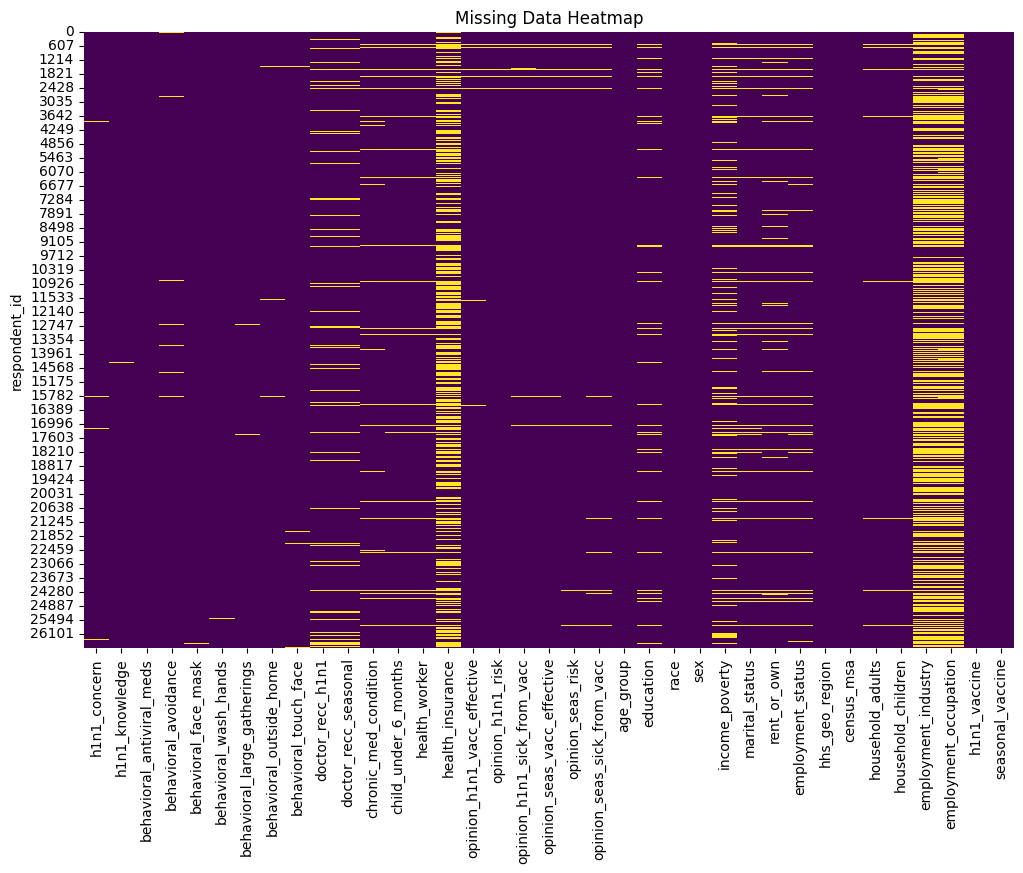

In [76]:
plt.figure(figsize=(12, 8))

# Missing Data Heatmap
sns.heatmap(new_merged.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [77]:
new_merged.isna().sum()

,0
h1n1_concern,92
h1n1_knowledge,116
behavioral_antiviral_meds,71
behavioral_avoidance,208
behavioral_face_mask,19
behavioral_wash_hands,42
behavioral_large_gatherings,87
behavioral_outside_home,82
behavioral_touch_face,128
doctor_recc_h1n1,2160


In [78]:
new_merged.duplicated().sum()

np.int64(0)

### Correlation — Numeric Features vs Targets

#### We check the correlation between the numerical features and target variables.

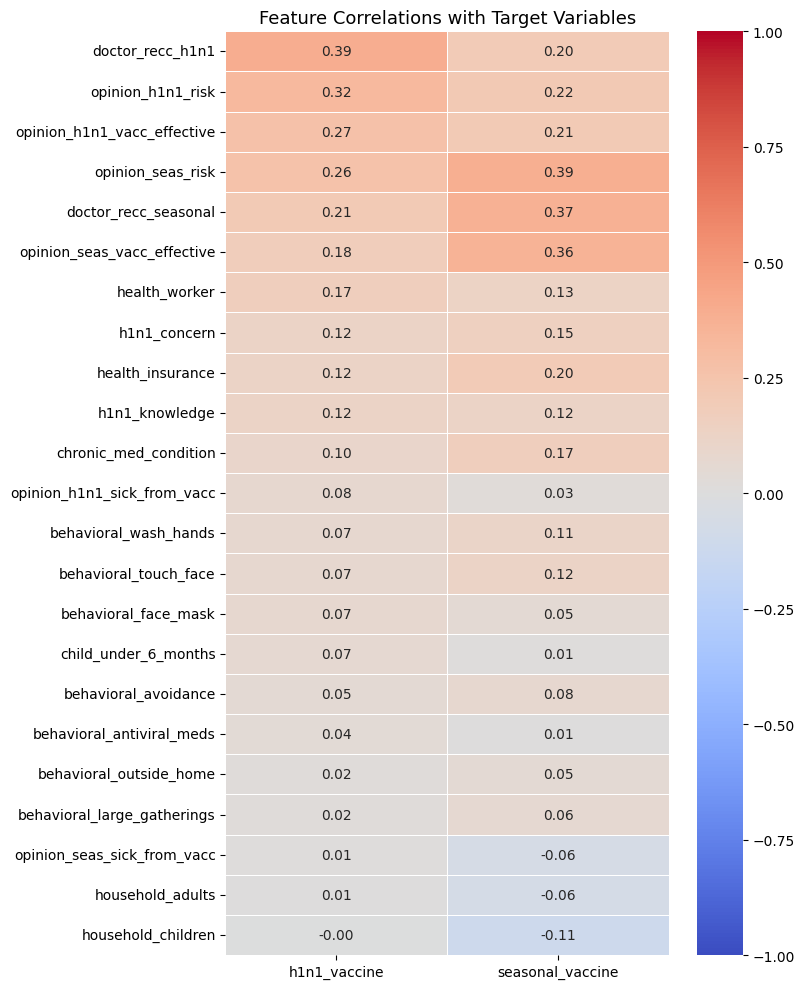

In [79]:
num_df = new_merged.select_dtypes(include='number')
corr_with_targets = num_df.corr()[['h1n1_vaccine', 'seasonal_vaccine']].drop(
    ['h1n1_vaccine', 'seasonal_vaccine']
).sort_values('h1n1_vaccine', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_targets, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlations with Target Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Categorical Features — Vaccine Uptake by Group

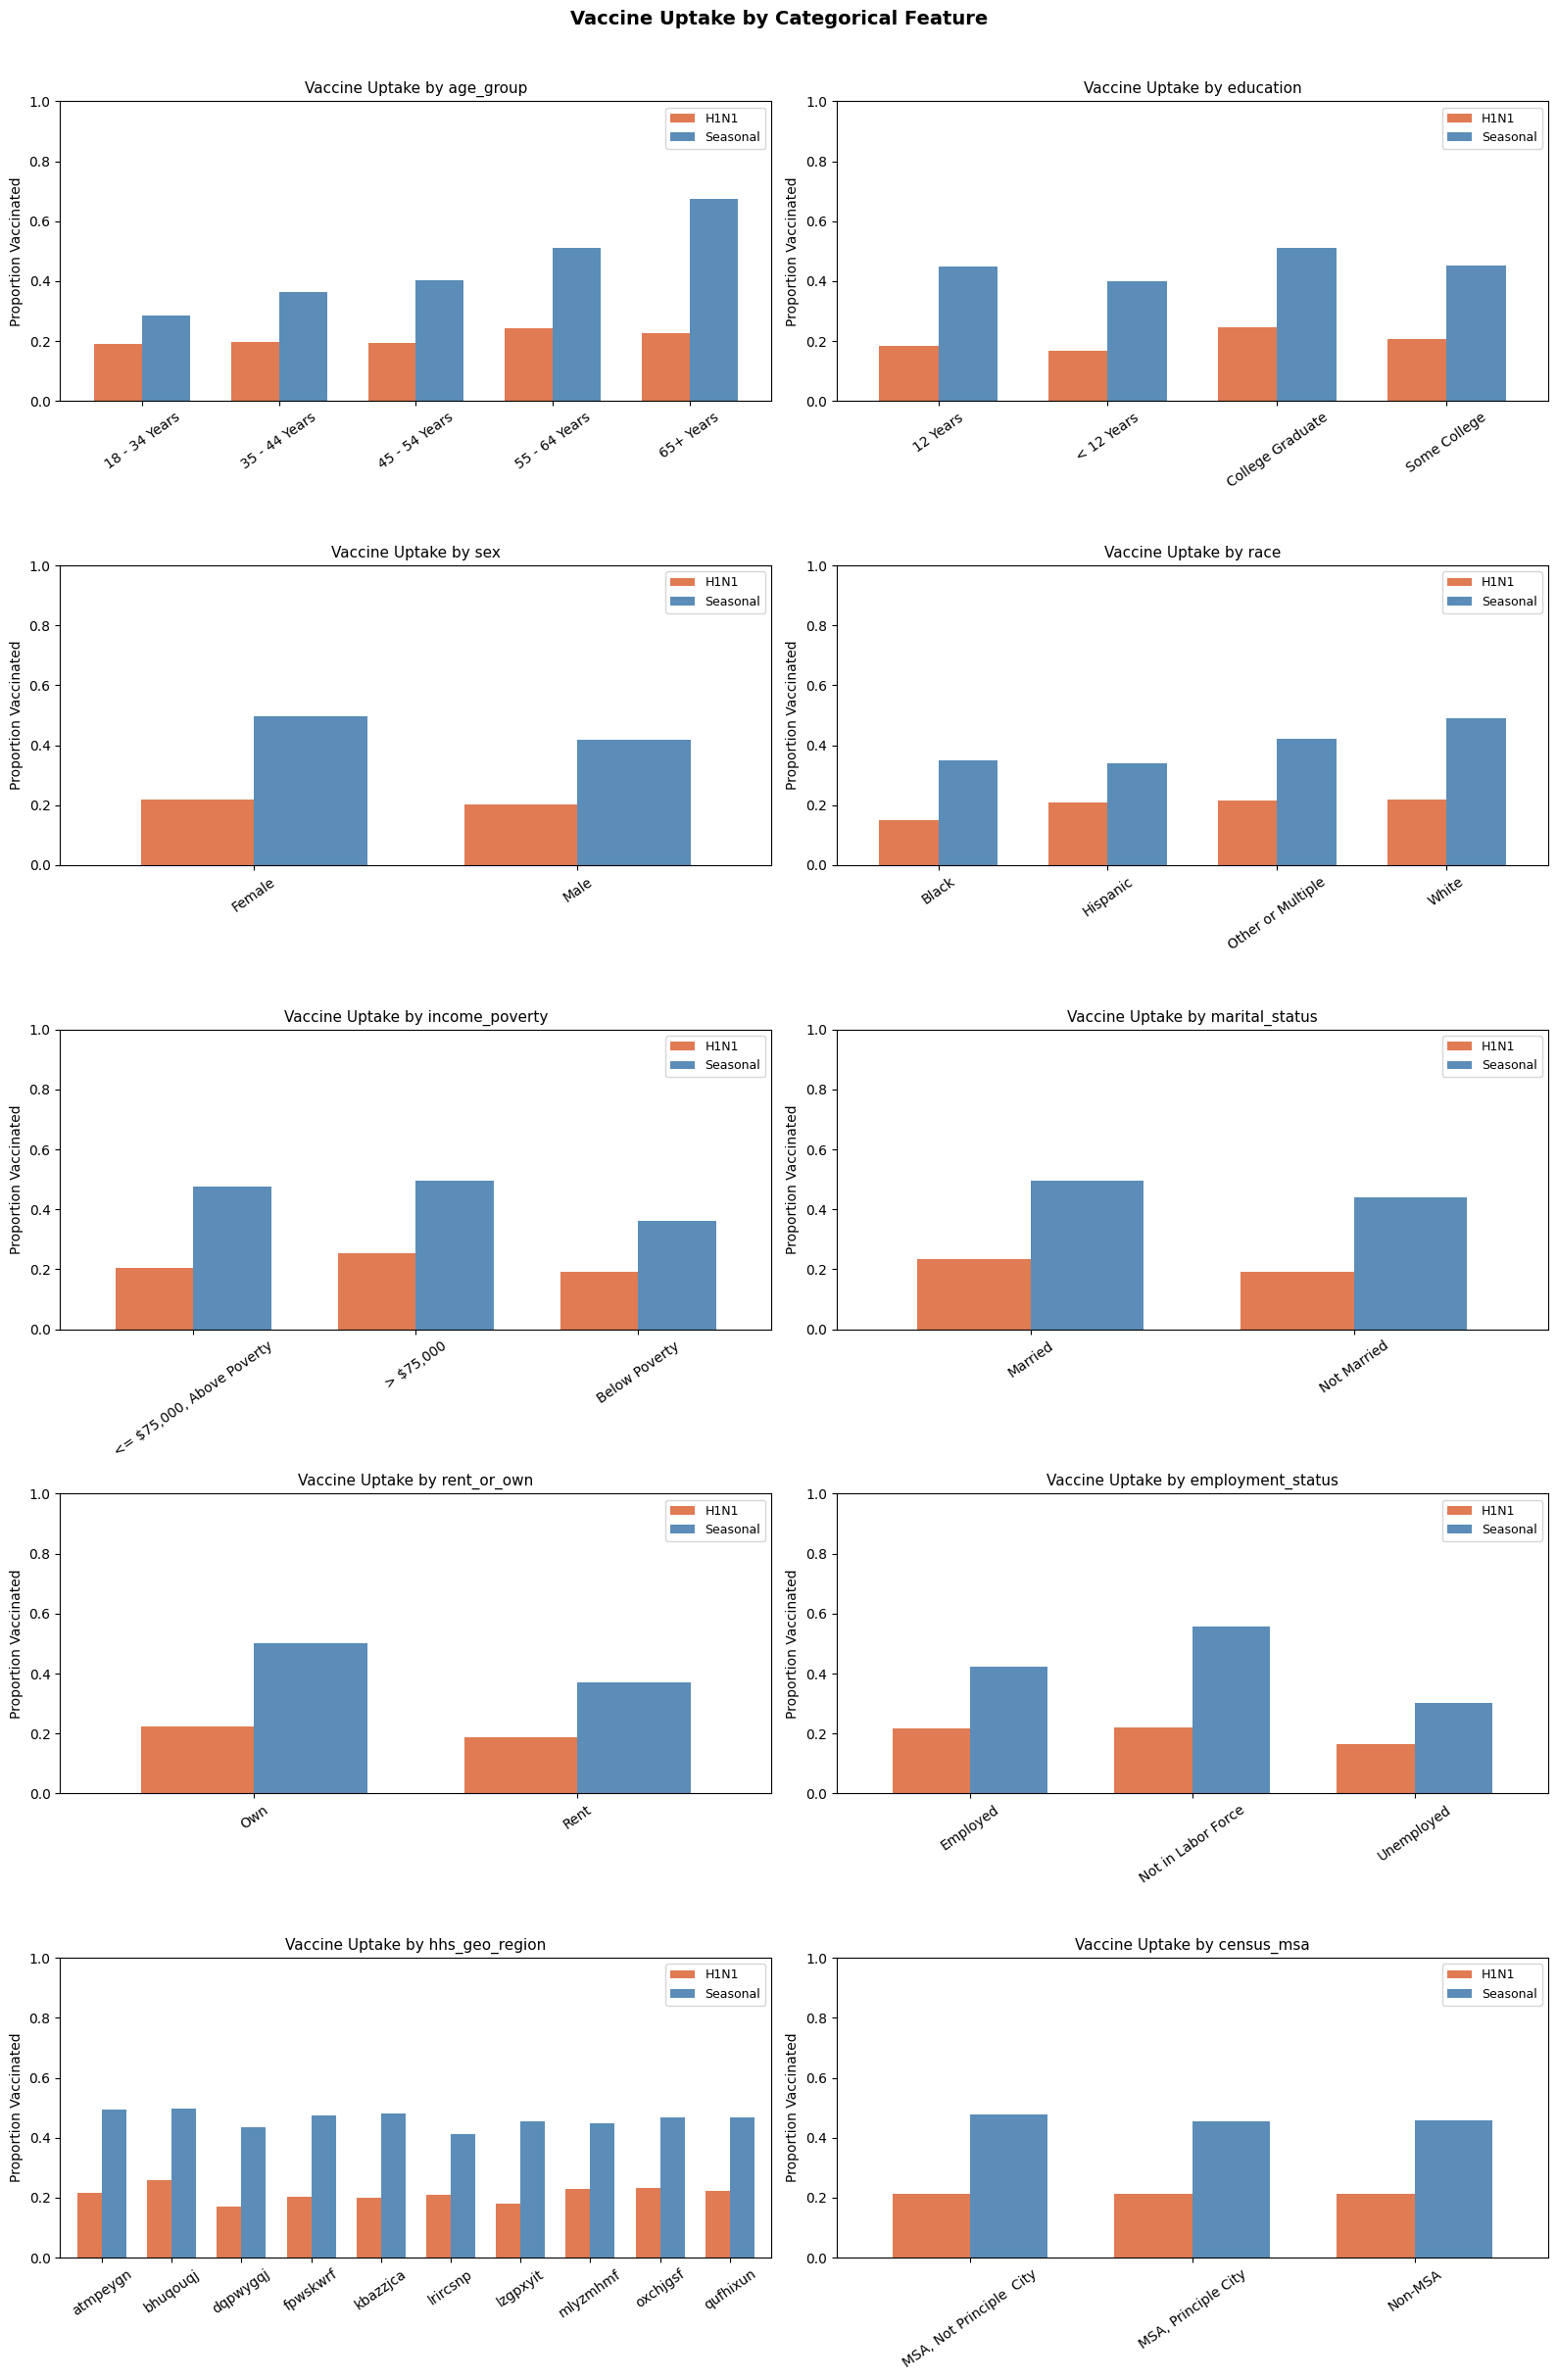

In [80]:
cat_features = [
    'age_group', 'education', 'sex', 'race',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'hhs_geo_region', 'census_msa'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    uptake = new_merged.groupby(col)[['h1n1_vaccine', 'seasonal_vaccine']].mean()
    uptake.plot(kind='bar', ax=axes[i], color=['#e07b54', '#5b8db8'], width=0.7)
    axes[i].set_title(f'Vaccine Uptake by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion Vaccinated')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['H1N1', 'Seasonal'], fontsize=9)
    axes[i].set_ylim(0, 1)

plt.suptitle('Vaccine Uptake by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### GROUPING WHO GOT EITHER VACCINES, NONE, OR BOTH

In [81]:
def vaccine_group(row):
    if row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 1:
        return 'Both Vaccines'
    elif row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 0:
        return 'H1N1 Only'
    elif row['h1n1_vaccine'] == 0 and row['seasonal_vaccine'] == 1:
        return 'Seasonal Only'
    else:
        return 'Neither Vaccine'
new_merged['vaccine_group'] = new_merged.apply(vaccine_group, axis=1)

In [82]:
# Count and percentage
group_counts = new_merged['vaccine_group'].value_counts()
group_pct    = (group_counts / len(new_merged) * 100).round(1)
print(pd.DataFrame({'Count': group_counts, '%': group_pct}))

                 Count     %
vaccine_group               
Neither Vaccine  13295  49.8
Seasonal Only     7738  29.0
Both Vaccines     4697  17.6
H1N1 Only          977   3.7


### Defining my X and Y variables

In [83]:
X = new_merged.drop(columns=['h1n1_vaccine', 'seasonal_vaccine','vaccine_group'])

y = new_merged[['h1n1_vaccine', 'seasonal_vaccine']]

### SPLITTING MY DATA

In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [85]:
X_train.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Below Poverty,Married,Rent,Unemployed,lzgpxyit,"MSA, Not Principle City",1.0,0.0,NaN,NaN
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,"> $75,000",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0,wxleyezf,emcorrxb
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,NaN,Married,NaN,Employed,qufhixun,"MSA, Not Principle City",1.0,1.0,xicduogh,xtkaffoo
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,Not Married,Own,Employed,bhuqouqj,Non-MSA,0.0,0.0,cfqqtusy,ukymxvdu
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,mlyzmhmf,"MSA, Principle City",1.0,1.0,NaN,NaN


In [86]:
y_train.head()

,h1n1_vaccine,seasonal_vaccine
respondent_id,,
24706,0,0
5393,0,1
20898,1,1
3429,0,0
8731,0,0


In [87]:
X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,atmpeygn,"MSA, Principle City",NaN,NaN,NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",1.0,1.0,NaN,NaN
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,NaN,Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",0.0,1.0,mfikgejo,mxkfnird
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"> $75,000",Married,Own,Employed,bhuqouqj,Non-MSA,1.0,2.0,cfqqtusy,xtkaffoo
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",1.0,0.0,wxleyezf,xtkaffoo


#### EXPLORING MY SPLIT DATA

#### FOR X_TRAIN

In [88]:
X_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 21365 entries, 24706 to 23654
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 21292 non-null  float64
 1   h1n1_knowledge               21274 non-null  float64
 2   behavioral_antiviral_meds    21306 non-null  float64
 3   behavioral_avoidance         21202 non-null  float64
 4   behavioral_face_mask         21351 non-null  float64
 5   behavioral_wash_hands        21329 non-null  float64
 6   behavioral_large_gatherings  21293 non-null  float64
 7   behavioral_outside_home      21306 non-null  float64
 8   behavioral_touch_face        21263 non-null  float64
 9   doctor_recc_h1n1             19629 non-null  float64
 10  doctor_recc_seasonal         19629 non-null  float64
 11  chronic_med_condition        20594 non-null  float64
 12  child_under_6_months         20710 non-null  float64
 13  health_worker    

In [89]:
X_train.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [90]:
X_train.shape

(21365, 35)

In [91]:
X_train.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,21292.000000,21274.000000,21306.000000,21202.000000,21351.000000,21329.000000,21293.000000,21306.000000,21263.000000,19629.000000,...,20722.000000,11507.000000,21047.000000,21054.000000,21044.000000,20994.000000,20955.000000,20934.000000,21163.000000,21163.000000
mean,1.618026,1.265018,0.049329,0.724507,0.070348,0.823574,0.357864,0.337464,0.675728,0.221662,...,0.113840,0.879465,3.848910,2.345730,2.361196,4.029532,2.722023,2.121286,0.888910,0.535888
std,0.909311,0.617816,0.216559,0.446773,0.255739,0.381192,0.479383,0.472856,0.468113,0.415375,...,0.317625,0.325601,1.008976,1.287865,1.362904,1.082279,1.385780,1.335174,0.754466,0.929504
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [92]:
X_train.isna().sum()

,0
h1n1_concern,73
h1n1_knowledge,91
behavioral_antiviral_meds,59
behavioral_avoidance,163
behavioral_face_mask,14
behavioral_wash_hands,36
behavioral_large_gatherings,72
behavioral_outside_home,59
behavioral_touch_face,102
doctor_recc_h1n1,1736


In [93]:
X_train.duplicated().sum()

np.int64(0)

#### FOR X_TEST

In [94]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5342 entries, 15772 to 12943
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 5323 non-null   float64
 1   h1n1_knowledge               5317 non-null   float64
 2   behavioral_antiviral_meds    5330 non-null   float64
 3   behavioral_avoidance         5297 non-null   float64
 4   behavioral_face_mask         5337 non-null   float64
 5   behavioral_wash_hands        5336 non-null   float64
 6   behavioral_large_gatherings  5327 non-null   float64
 7   behavioral_outside_home      5319 non-null   float64
 8   behavioral_touch_face        5316 non-null   float64
 9   doctor_recc_h1n1             4918 non-null   float64
 10  doctor_recc_seasonal         4918 non-null   float64
 11  chronic_med_condition        5142 non-null   float64
 12  child_under_6_months         5177 non-null   float64
 13  health_worker     

In [95]:
X_test.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [96]:
X_test.shape

(5342, 35)

In [97]:
X_test.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,5323.000000,5317.000000,5330.000000,5297.000000,5337.000000,5336.000000,5327.000000,5319.000000,5316.000000,4918.000000,...,5181.000000,2926.000000,5269.000000,5265.000000,5268.000000,5251.000000,5238.000000,5236.000000,5295.000000,5295.000000
mean,1.620327,1.252586,0.046904,0.730036,0.063519,0.833771,0.361742,0.336717,0.683409,0.214925,...,0.104227,0.880725,3.857468,2.329915,2.343584,4.011807,2.707713,2.105424,0.876865,0.529367
std,0.914381,0.619439,0.211454,0.443983,0.243917,0.372321,0.480550,0.472632,0.465190,0.410812,...,0.305584,0.324168,1.001324,1.276240,1.362251,1.103524,1.382224,1.324070,0.749224,0.922905
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,4.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [98]:
X_test.isna().sum()

,0
h1n1_concern,19
h1n1_knowledge,25
behavioral_antiviral_meds,12
behavioral_avoidance,45
behavioral_face_mask,5
behavioral_wash_hands,6
behavioral_large_gatherings,15
behavioral_outside_home,23
behavioral_touch_face,26
doctor_recc_h1n1,424


In [99]:
X_test.duplicated().sum()

np.int64(0)

## DATA CLEANING AND PREPROCESSING

#### 1. Dropping unnecessary columns

In [100]:

new_X_train = X_train.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_train.head()


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
24706,2.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Some College,White,Female,Below Poverty,Married,Rent,Unemployed,"MSA, Not Principle City",1.0,0.0
5393,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,White,Male,"> $75,000",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0
20898,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,NaN,White,Male,NaN,Married,NaN,Employed,"MSA, Not Principle City",1.0,1.0
3429,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,Other or Multiple,Female,NaN,Not Married,Own,Employed,Non-MSA,0.0,0.0
8731,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,Black,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",1.0,1.0


In [101]:
new_X_test = X_test.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,White,Female,NaN,NaN,NaN,NaN,"MSA, Principle City",NaN,NaN
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,NaN,...,NaN,White,Male,NaN,NaN,NaN,NaN,"MSA, Principle City",1.0,1.0
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,White,Female,NaN,Not Married,Own,Employed,"MSA, Not Principle City",0.0,1.0
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,White,Female,"> $75,000",Married,Own,Employed,Non-MSA,1.0,2.0
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,White,Male,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,0.0


#### 2. FILLING MISSING VALUES

##### Filling Missing values for X_train

## Create copies of dataset
### We create copies , in order not to make permernent changes to our initial dataset.

In [102]:
#Filling Missing values for X_train
numerical_columns = new_X_train.select_dtypes(include='number').columns.tolist()
numerical_columns

['h1n1_concern',
 'h1n1_knowledge',
 'behavioral_antiviral_meds',
 'behavioral_avoidance',
 'behavioral_face_mask',
 'behavioral_wash_hands',
 'behavioral_large_gatherings',
 'behavioral_outside_home',
 'behavioral_touch_face',
 'doctor_recc_h1n1',
 'doctor_recc_seasonal',
 'chronic_med_condition',
 'child_under_6_months',
 'health_worker',
 'health_insurance',
 'opinion_h1n1_vacc_effective',
 'opinion_h1n1_risk',
 'opinion_h1n1_sick_from_vacc',
 'opinion_seas_vacc_effective',
 'opinion_seas_risk',
 'opinion_seas_sick_from_vacc',
 'household_adults',
 'household_children']

In [103]:
categorical_columns = new_X_train.select_dtypes(include='object').columns.tolist()

categorical_columns

['age_group',
 'education',
 'race',
 'sex',
 'income_poverty',
 'marital_status',
 'rent_or_own',
 'employment_status',
 'census_msa']

In [104]:
numerical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_clean = X_train.copy()
X_train_clean_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
X_train_clean_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

# X_train_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
# X_train_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

##### Filling Missing values for X_test

In [105]:
X_test_clean = X_test.copy()
X_test_clean_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
X_test_clean_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)

# X_test_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
# X_test_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)


#### 3. Checking For Outliers
The numeric features in this dataset are either binary,0 or 1,or ordinal scales,1–5. Because the values are bounded, any extreme responses are still valid answers and not errors. The models to be used are also not heavily affected by outliers. No rows removed.

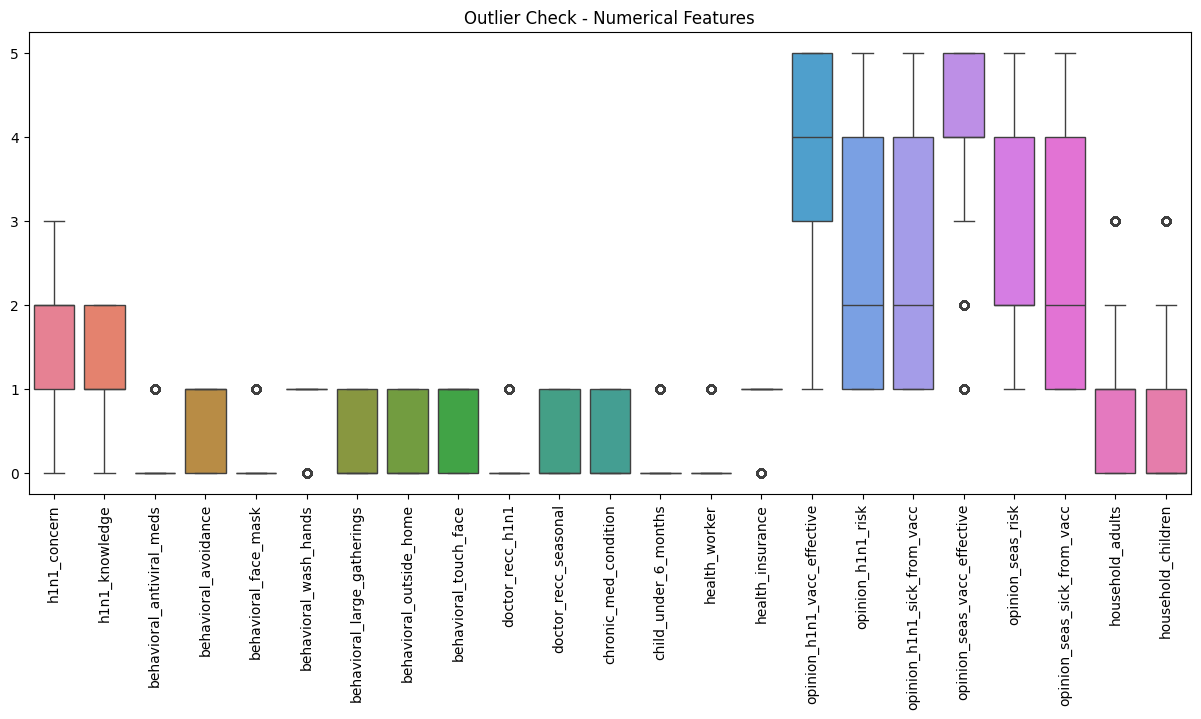

In [106]:
plt.figure(figsize=(15,6))
sns.boxplot(data=X_train[numerical_columns])
plt.xticks(rotation=90)
plt.title("Outlier Check - Numerical Features")
plt.show()

The boxplots reveal the presence of some outliers across numerical features, but they are not overly extreme or widespread. These values are retained as they may represent genuine variations rather than errors and are unlikely to significantly distort the models.

### EXPLORATORY DATA ANALYSIS- PART 2

#### 1. UNIVARIATE ANALYSIS

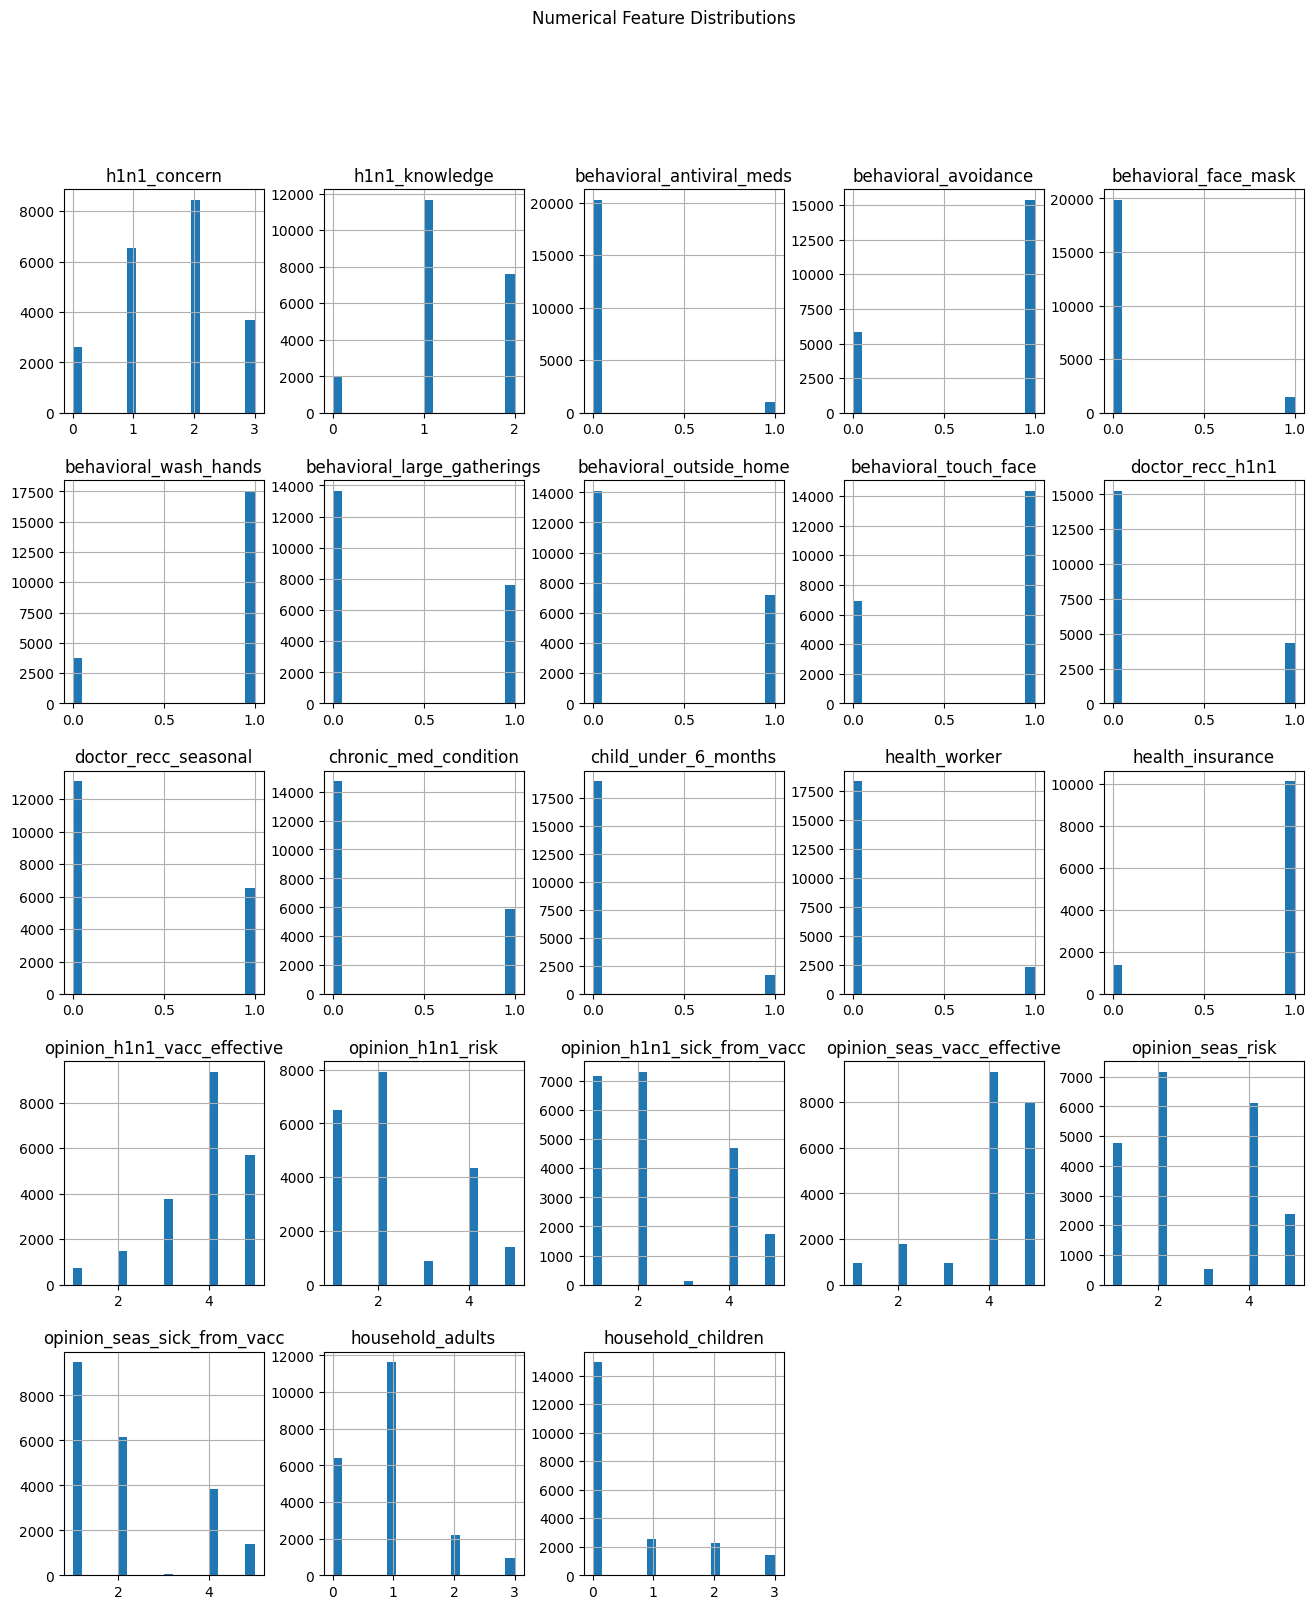

In [107]:
#NUMERICAL FEATURES
X_train[numerical_columns].hist(figsize=(16,18), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [108]:
#CATEGORICAL FEATURES
for col in categorical_columns:
    print(f"\n{col}")
    print(X_train[col].value_counts(normalize=True).head())


age_group
age_group
65+ Years        0.255277
55 - 64 Years    0.208799
18 - 34 Years    0.197145
45 - 54 Years    0.195834
35 - 44 Years    0.142944
Name: proportion, dtype: float64

education
education
College Graduate    0.398370
Some College        0.279941
12 Years            0.229051
< 12 Years          0.092638
Name: proportion, dtype: float64

race
race
White                0.794477
Black                0.077510
Hispanic             0.066136
Other or Multiple    0.061877
Name: proportion, dtype: float64

sex
sex
Female    0.596677
Male      0.403323
Name: proportion, dtype: float64

income_poverty
income_poverty
<= $75,000, Above Poverty    0.577055
> $75,000                    0.303905
Below Poverty                0.119041
Name: proportion, dtype: float64

marital_status
marital_status
Married        0.537417
Not Married    0.462583
Name: proportion, dtype: float64

rent_or_own
rent_or_own
Own     0.760602
Rent    0.239398
Name: proportion, dtype: float64

employment_status
e

The univariate analysis shows that several numerical features are skewed, while categorical variables are often imbalanced with dominant categories. This highlights the need for proper preprocessing before modeling.

#### 2. BIVARIATE ANALYSIS- TARGET VS FEATURES
a) Numerical vs Target

In [109]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

b) Categorical vs Target

In [110]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.811491  0.188509
35 - 44 Years  0.802554  0.197446
45 - 54 Years  0.803537  0.196463
55 - 64 Years  0.759247  0.240753
65+ Years      0.770627  0.229373

education
h1n1_vaccine             0         1
education                           
12 Years          0.816437  0.183563
< 12 Years        0.837867  0.162133
College Graduate  0.754062  0.245938
Some College      0.788387  0.211613

race
h1n1_vaccine              0         1
race                                 
Black              0.847826  0.152174
Hispanic           0.799009  0.200991
Other or Multiple  0.788956  0.211044
White              0.780311  0.219689

sex
h1n1_vaccine         0         1
sex                             
Female        0.781064  0.218936
Male          0.796565  0.203435

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.794195  0.

The bivariate analysis indicates clear relationships between features and the target variables, suggesting that both demographic and behavioral factors influence vaccination outcomes and will be useful for prediction.

## PRE-PROCESSING

### ENCODING CATEGORICAL COLUMNS

In [111]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_train_clean.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_test_clean.index)


#### CONCATINATION

In [112]:
Final_X_train = pd.concat([X_train_clean_num, X_train_ohe], axis=1)
Final_X_test = pd.concat([X_test_clean_num, X_test_ohe], axis=1)

## MODELLING


Training **separate binary classifiers** for each target variable.

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline — fast & interpretable |
| Decision Tree | Intermediate — non-linear, easy to explain |
| Random Forest (tuned) | Final model — strong performance |

**Primary metric:** ROC-AUC (ranges 0.5–1.0; higher is better)

# MODEL 1

### 1. Baseline — Logistic Regression

In [113]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Final_X_train)
X_test_scaled = scaler.transform(Final_X_test)

lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("H1N1 Accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_pred[:, 0]))
print("Seasonal Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_pred[:, 1]))

H1N1 Accuracy: 0.8423811306626732
Seasonal Accuracy: 0.7832272557094722


## Interpretation of my accuracy results
1.) H1N Accuracy - Out of all the thousands of patients in the test data, my Logistic Regression model looked at the urveys and correctly predicted whether they got the H1N1 vaccine or not 82.8% of the time.

2.) Seasonal Accuracy - Just like the H1N1 score, my your model looked at thousands of new test patients it had never seen before, checked out their survey answers, and successfully predicted their Seasonal vaccine status 76.17% of the time.

In [114]:
# Define the baseline model
base_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Train it on the training data
base_lr.fit(X_train_scaled, y_train)
print("Base Logistic Regression model trained successfully!")


Base Logistic Regression model trained successfully!


In [115]:
logreg = MultiOutputClassifier(LogisticRegression(fit_intercept=False, solver='liblinear'))
model_log = logreg.fit(X_train_scaled, y_train)
model_log

MultiOutputClassifier(estimator=LogisticRegression(fit_intercept=False,
                                                   solver='liblinear'))

## CHECKING FOR CLASS IMBALANCE IN MY DATA

Happens when one class appears more often than the other in a dataset.
A model built on imbalanced datasets tends to be lazy and always predicts the majority class.

In [116]:
# 1. Check the H1N1 Vaccine percentages
print("H1N1 Vaccine Split:")
print(y_train['h1n1_vaccine'].value_counts(normalize=True))

# 2. Check the Seasonal Vaccine percentages
print("\nSeasonal Vaccine Split:")
print(y_train['seasonal_vaccine'].value_counts(normalize=True))


 # 3. Check the value counts
print(y_train['h1n1_vaccine'].value_counts())
print(y_train['seasonal_vaccine'].value_counts())



H1N1 Vaccine Split:
h1n1_vaccine
0    0.787316
1    0.212684
Name: proportion, dtype: float64

Seasonal Vaccine Split:
seasonal_vaccine
0    0.532694
1    0.467306
Name: proportion, dtype: float64
h1n1_vaccine
0    16821
1     4544
Name: count, dtype: int64
seasonal_vaccine
0    11381
1     9984
Name: count, dtype: int64


Presence of class imbalance in H1N1 vaccine data.Class 0 has 78% and class 1 has 22%, with class 0 having the majority by a higher percentage.  Built models with this imbalance will tend to make my predictions lazy, by them predicting the majority class.

My seasonal vaccine data is almost balanced, with class 0 having 54% and class 1 having 46%. There is no need to remove imbalance in seasonal vaccine data.

### HANDLING IMBALANCED DATASET USING SMOTE

 Steps in Synthetic Minority Oversampling Technique:

    - Pick a minority point

    - Find its nearest neighbors

    - Create a new point between them


In [117]:

# 1. Handling Imbalanced for H1N1 Vaccine
y_train_h1n1 = y_train['h1n1_vaccine']

# 2. Balance the features and the target instantly
smote = SMOTE(random_state=42)
X_train_h1n1_smoted, y_train_h1n1_smoted = smote.fit_resample(X_train_scaled, y_train_h1n1)

# 3. Print the new balanced counts
print("New H1N1 Counts After SMOTE:\n", pd.Series(y_train_h1n1_smoted).value_counts())


New H1N1 Counts After SMOTE:
 h1n1_vaccine
0    16821
1    16821
Name: count, dtype: int64


# MODEL 2

### BUILDING SMOTE MODEL

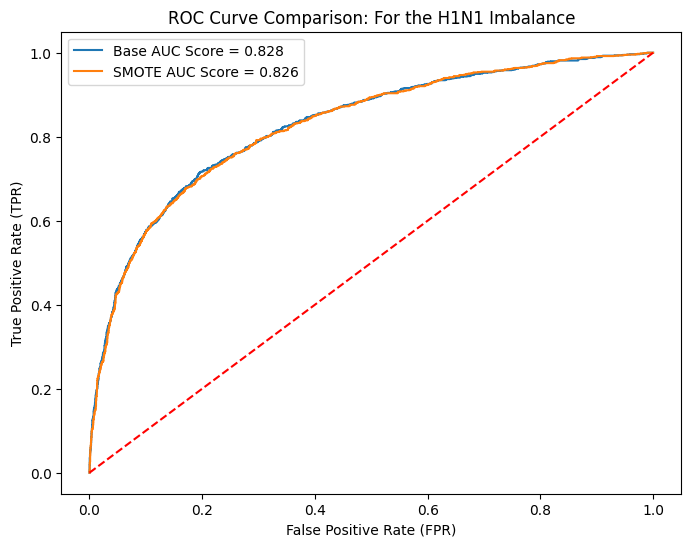

In [118]:
# Only comparing H1N1 since it is the imbalanced target!
y_train_h1n1 = y_train['h1n1_vaccine']
y_test_h1n1 = y_test['h1n1_vaccine']


# 1. THE BASE MODEL (Untuned)

base_model = LogisticRegression(solver='liblinear', random_state=42)
base_model.fit(X_train_scaled, y_train_h1n1)

scores_base = base_model.decision_function(X_test_scaled)
fpr_base, tpr_base, thresholds_base = roc_curve(y_test_h1n1, scores_base)
auc_base = roc_auc_score(y_test_h1n1, scores_base)



# 2. THE SMOTE MODEL
smote_model = LogisticRegression(solver='liblinear', random_state=42)
smote_model.fit(X_train_h1n1_smoted, y_train_h1n1_smoted)

scores_smote = smote_model.decision_function(X_test_scaled)
fpr_smote, tpr_smote, thresholds_smote = roc_curve(y_test_h1n1, scores_smote)
auc_smote = roc_auc_score(y_test_h1n1, scores_smote)



# PLOTTING THE ROC CURVES

plt.figure(figsize=(8,6))

# Plot all two lines
plt.plot(fpr_base, tpr_base, label=f"Base AUC Score = {auc_base:.3f}")

plt.plot(fpr_smote, tpr_smote, label=f"SMOTE AUC Score = {auc_smote:.3f}")

# Plot the 50/50 randomized guess baseline (the red dashed line)
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title('ROC Curve Comparison: For the H1N1 Imbalance')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend()
plt.show()


The ROC curves for all Logistic Regression models perfectly overlap because it is a strict linear algorithm. While SMOTE successfully shifted the probability cutoff point to improve our minority class detection , it mathematically cannot bend the underlying straight line to capture a higher Area Under the Curve (AUC).

#### Classification Report for Baseline Model

In [123]:
base_model = LogisticRegression(solver='liblinear', random_state=42)
base_model.fit(X_train_scaled, y_train_h1n1)


base_model_seasonal = LogisticRegression(solver='liblinear', random_state=42)
base_model_seasonal.fit(X_train_scaled, y_train['seasonal_vaccine'])

y_pred_h1n1_base = base_model.predict(X_test_scaled)
y_pred_seas_base = base_model_seasonal.predict(X_test_scaled)

# Print out the raw untouched Baseline reports!
print("--- H1N1 BASELINE LOGISTIC REGRESSION (Raw Data) ---")
print(classification_report(y_test_h1n1, y_pred_h1n1_base))

print("\n\n--- SEASONAL BASELINE LOGISTIC REGRESSION (Raw Data) ---")
print(classification_report(y_test['seasonal_vaccine'], y_pred_seas_base))


--- H1N1 BASELINE LOGISTIC REGRESSION (Raw Data) ---
              precision    recall  f1-score   support

           0       0.86      0.95      0.91      4212
           1       0.71      0.43      0.54      1130

    accuracy                           0.84      5342
   macro avg       0.79      0.69      0.72      5342
weighted avg       0.83      0.84      0.83      5342



--- SEASONAL BASELINE LOGISTIC REGRESSION (Raw Data) ---
              precision    recall  f1-score   support

           0       0.79      0.82      0.80      2891
           1       0.77      0.74      0.76      2451

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



#### Classification Report for SMOTE Model




In [124]:


y_pred_h1n1_smote = smote_model.predict(X_test_scaled)

#  Printing out the Precision, Recall, and F1-Scores!
print("--- SMOTE LOGISTIC REGRESSION REPORT (H1N1) ---")
print(classification_report(y_test_h1n1, y_pred_h1n1_smote))


--- SMOTE LOGISTIC REGRESSION REPORT (H1N1) ---
              precision    recall  f1-score   support

           0       0.91      0.79      0.85      4212
           1       0.48      0.71      0.57      1130

    accuracy                           0.78      5342
   macro avg       0.70      0.75      0.71      5342
weighted avg       0.82      0.78      0.79      5342



The SMOTE model applies only to H1N1 data, since it had the class imbalance.

### Comparison of recall between Base model and Smote model

Recall for Class one improved immensely in Class 1, the minority class, meaning the model improved.

# MODEL 3

### DECISION TREE MODEL

In [131]:


# 1.H1N1 Decision Tree - after dealing with class imbalance
decision_tree_h1n1 = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree_h1n1.fit(X_train_h1n1_smoted, y_train_h1n1_smoted)

# 2. Seasonal Decision Tree - Using data as it is, it is balanced
dt_seasonal = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_seasonal.fit(X_train_scaled, y_train['seasonal_vaccine'])

# 3. Print the new Accuracies!
print("--- DECISION TREE ACCURACY ---")
print("H1N1 Accuracy:", dt_h1n1.score(X_test_scaled, y_test_h1n1))
print("Seasonal Accuracy:", dt_seasonal.score(X_test_scaled, y_test['seasonal_vaccine']))


--- DECISION TREE ACCURACY ---
H1N1 Accuracy: 0.8189816548109322
Seasonal Accuracy: 0.7598277798577312


### COMPARISON FOR THE 3 MODELS USING AUC

We get to know which model is the best among the three by picking most top left curve, as it will have highest AUC curve

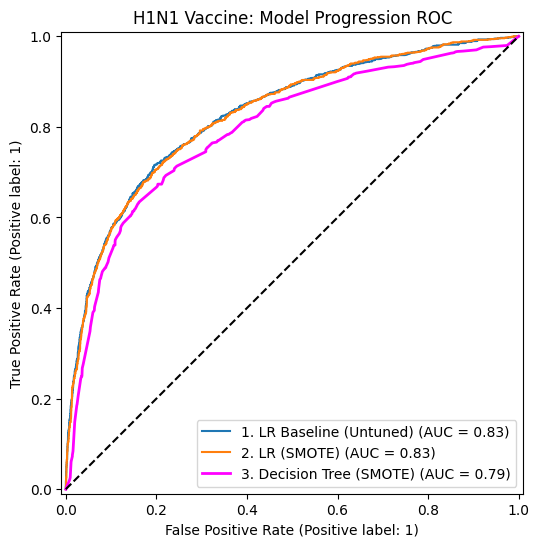

In [126]:
# FOR TARGET VARIABLE H1N1
fig, ax = plt.subplots(figsize=(8, 6))

# Plot all 3 H1N1 models
RocCurveDisplay.from_estimator(base_model, X_test_scaled, y_test_h1n1, ax=ax, name="1. LR Baseline (Untuned)")
RocCurveDisplay.from_estimator(smote_model, X_test_scaled, y_test_h1n1, ax=ax, name="2. LR (SMOTE)")
RocCurveDisplay.from_estimator(dt_h1n1, X_test_scaled, y_test_h1n1, ax=ax, name="3. Decision Tree (SMOTE)", color="magenta", linewidth=2)

ax.plot([0,1], [0,1], linestyle='--', color='black')
ax.set_title("H1N1 Vaccine: Model Progression ROC")

plt.show()


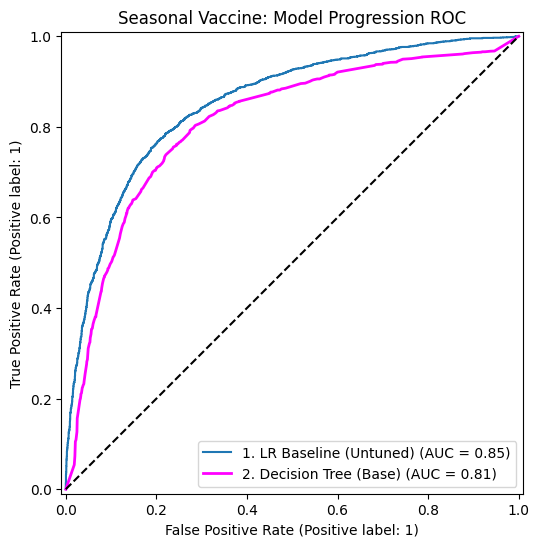

In [127]:
#FOR TARGET VARIABLE SEASONAL VACCINE
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the 2 Seasonal models
RocCurveDisplay.from_estimator(base_model_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax, name="1. LR Baseline (Untuned)")
RocCurveDisplay.from_estimator(dt_seasonal, X_test_scaled, y_test['seasonal_vaccine'], ax=ax, name="2. Decision Tree (Base)", color="magenta", linewidth=2)

ax.plot([0,1], [0,1], linestyle='--', color='black')
ax.set_title("Seasonal Vaccine: Model Progression ROC")

plt.show()


In an attempt to bend around the data's complexity using a non-linear model, the Decision Tree model actually underperformed the Baseline constraint. This indicates classic overfitting, the Decision Tree memorized the noisy, synthetic points from our SMOTE operation during training, leading it to fail at generalizing the actual real-world test data.

### Classification Report for Decision Tree Model

In [130]:
from sklearn.metrics import classification_report


y_pred_h1n1_dt = dt_h1n1.predict(X_test_scaled)
y_pred_seas_dt = dt_seasonal.predict(X_test_scaled)

# Print the Precision, Recall, and F1 for the Decision Trees
print("--- H1N1 DECISION TREE REPORT (Trained on SMOTE data) ---")
print(classification_report(y_test_h1n1, y_pred_h1n1_dt))

print("\n\n--- SEASONAL DECISION TREE REPORT (Trained on Original data) ---")
print(classification_report(y_test['seasonal_vaccine'], y_pred_seas_dt))


--- H1N1 DECISION TREE REPORT (Trained on SMOTE data) ---
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4212
           1       0.58      0.53      0.55      1130

    accuracy                           0.82      5342
   macro avg       0.73      0.71      0.72      5342
weighted avg       0.81      0.82      0.82      5342



--- SEASONAL DECISION TREE REPORT (Trained on Original data) ---
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      2891
           1       0.74      0.73      0.74      2451

    accuracy                           0.76      5342
   macro avg       0.76      0.76      0.76      5342
weighted avg       0.76      0.76      0.76      5342



* **H1N1 Decision Tree:** The model dropped to `0.53` Recall. Because it attempted to build deep non-linear rules to memorize the synthetic SMOTE data, it overfit and failed to generalize to the real testing patients.


* **Seasonal Decision Tree:** Training on the perfectly balanced, unaltered data proved much more stable, yielding a strong, consistent `0.73` Recall without succumbing to overfitting.
